In [4]:
!pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
  Using cached torchaudio-2.11.0-cp313-cp313-win_amd64.whl.metadata (6.9 kB)
Using cached torchaudio-2.11.0-cp313-cp313-win_amd64.whl (328 kB)


In [5]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cu130
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [6]:
import sys
print(sys.executable)

c:\Program Files\Python313\python.exe


##  Training the conventional way (No PINN Method)

In [7]:
import torch
import torch.nn as nn

# 2 input neurons (x, y) -> 5 hidden layers of 20 tanh neurons -> 1 output neuron (u)

""" It takes two input and passes them through the five tanh() layers and returns a single output.
In total the network ends up with 1761 parameters. """
model = nn.Sequential(
    nn.Linear(2, 20), nn.Tanh(),
    nn.Linear(20, 20), nn.Tanh(),
    nn.Linear(20, 20), nn.Tanh(),
    nn.Linear(20, 20), nn.Tanh(),
    nn.Linear(20, 20), nn.Tanh(),
    nn.Linear(20, 1),
)

print(model)
print(f"Total params: {sum(p.numel() for p in model.parameters())}")

# the heat across the metal
def u(x, y):
    return model(torch.cat([x, y], dim=1))

Sequential(
  (0): Linear(in_features=2, out_features=20, bias=True)
  (1): Tanh()
  (2): Linear(in_features=20, out_features=20, bias=True)
  (3): Tanh()
  (4): Linear(in_features=20, out_features=20, bias=True)
  (5): Tanh()
  (6): Linear(in_features=20, out_features=20, bias=True)
  (7): Tanh()
  (8): Linear(in_features=20, out_features=20, bias=True)
  (9): Tanh()
  (10): Linear(in_features=20, out_features=1, bias=True)
)
Total params: 1761


##### Upto this point we have the wrong transformation from (x,y) --> u(x,y) becoz the network is not trained yet and it's free parameters just have some unadjusted initial values. 
##### Just to check that we have a transformation at all, we compute the wrong value of the heat u at x=0.1 and y=0.2 and it returns something like -0.96. It is meaning less for now but atleast it confirms the network is working.

In [8]:
x = torch.tensor([[0.1]])
y = torch.tensor([[0.2]])

u(x, y)

tensor([[0.0251]], grad_fn=<AddmmBackward0>)

#### To see the difference between pinns and conventional neural nets, let's first train this network the conventional way.
#### Meaning -> lets train it without physics just using data and no physics domain knowledge.

## Dataset

So, we first need to collect some data.

And for that, we need to get into our lab, take a thermometer and measure the temperature at some random  (x,y)  places across the surface of the metal.

This plot shows the random places at which we used our thermometer and measured the temperature

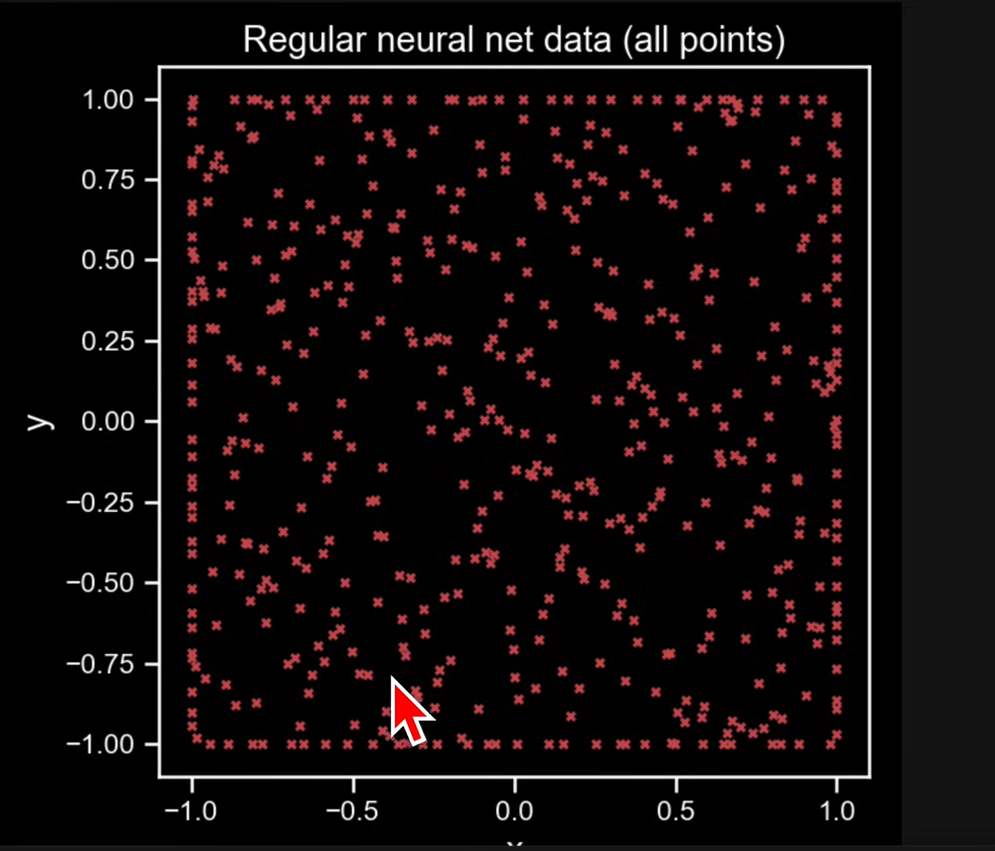


As you can see, we have data points at the boundary of the metal as well as throughout its surface.

In the following cell, we import our collected data into a dataframe so that we can use them for training a regular neural network.

In [9]:
import pandas as pd

df = pd.read_csv("Utils/regular_neural_net_data.csv")
df

,x,y,u
0,-1.000000,0.528675,0.720503
1,-1.000000,-0.056734,0.996781
2,-1.000000,-0.174259,0.969634
3,-1.000000,-0.718027,0.484438
4,-1.000000,-0.734127,0.461057
...,...,...,...
515,-0.800397,0.502741,0.387887
516,-0.338863,-0.725232,-0.411133
517,-0.909372,0.401079,0.666093
518,0.828855,-0.921264,-0.161727


## Loss Function

#### Now that we have defined the network, and collected our data, we need to define the loss function to minimize and train the model.

##### We define the loss function to be the conventional Mean Squared Error over the data points above:


$$
L(\theta) = \frac{1}{N} \sum_{i=1}^{N} \Bigg|u_{\theta}(x_i) - u_i^{data}\Bigg|^2
$$
#### Mean Squared Error over the data points that is the average of the squared difference between the network's prediction and the measured temperature.
#### Here  N  is the number of rows in the dataset.

#### Lets first implement this loss function in PyTorch

In [10]:
def mse(u_pred, u_true):
    return torch.mean((u_pred - u_true) ** 2)

## Training

#### Now let's minimize the loss function to find optimal values of the free parameters of the network.

#### In the following cell, we will use the gradient descent in PyTorch to perform the training.Specifically the adam optimizer to train the model for 62,000 epochs, as the training goes on, we can see the loss droping lower and lower until it becomes tiny and we plot the loss against the epochs on a log scale to watch it go down.


    0, 0.259344
  200, 0.001136
  400, 0.000054
  600, 0.000056
  800, 0.000032
 1000, 0.000027
 1200, 0.000023
 1400, 0.000021
 1600, 0.000019
 1800, 0.000017
 2000, 0.000016
 2200, 0.000015
 2400, 0.000013
 2600, 0.000012
 2800, 0.000070
 3000, 0.000010
 3200, 0.000009
 3400, 0.000147
 3600, 0.000008
 3800, 0.000007
 4000, 0.000089
 4200, 0.000006
 4400, 0.000005
 4600, 0.000005
 4800, 0.000004
 5000, 0.000005
 5200, 0.000004
 5400, 0.000240
 5600, 0.000003
 5800, 0.000003
 6000, 0.000002
 6200, 0.000002
 6400, 0.000002
 6600, 0.000002
 6800, 0.000002
 7000, 0.000002
 7200, 0.000002
 7400, 0.000001
 7600, 0.000001
 7800, 0.000001
 8000, 0.000001
 8200, 0.000001
 8400, 0.000001
 8600, 0.000001
 8800, 0.000001
 9000, 0.000001
 9200, 0.000001
 9400, 0.000001
 9600, 0.000017
 9800, 0.000001
10000, 0.000001
10200, 0.000001
10400, 0.000001
10600, 0.000027
10800, 0.000001
11000, 0.000001
11200, 0.000156
11400, 0.000001
11600, 0.000001
11800, 0.000001
12000, 0.000001
12200, 0.000001
12400, 0

<string>:134: AltairDeprecationWarning: 
Deprecated since `altair=5.5.0`. Use altair.theme instead.
Most cases require only the following change:

    # Deprecated
    alt.themes.enable('quartz')

    # Updated
    alt.theme.enable('quartz')

If your code registers a theme, make the following change:

    # Deprecated
    def custom_theme():
        return {'height': 400, 'width': 700}
    alt.themes.register('theme_name', custom_theme)
    alt.themes.enable('theme_name')

    # Updated
    @alt.theme.register('theme_name', enable=True)
    def custom_theme():
        return alt.theme.ThemeConfig(
            {'height': 400, 'width': 700}
        )

See the updated User Guide for further details:
    https://altair-viz.github.io/user_guide/api.html#theme
    https://altair-viz.github.io/user_guide/customization.html#chart-themes


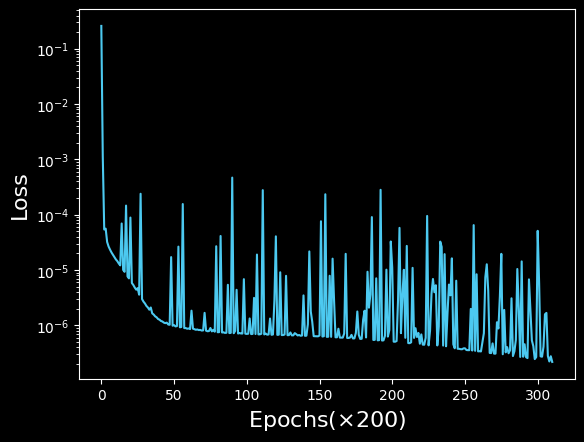

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# training data from df
x_train = torch.tensor(df["x"].values, dtype=torch.float32).unsqueeze(1)
y_train = torch.tensor(df["y"].values, dtype=torch.float32).unsqueeze(1)
u_train = torch.tensor(df["u"].values, dtype=torch.float32).unsqueeze(1)

# reset the model weights and get a fresh optimizer, so re-running this cell
# trains from scratch instead of continuing from an already-trained model
for m in model:
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# number of epochs (steps)
epochs = 62000
loss_values = np.array([])

for epoch in range(epochs):
    opt.zero_grad()
    loss = mse(u(x_train, y_train), u_train)
    loss.backward()
    opt.step()

    if epoch % 200 == 0 or epoch == epochs - 1:
        print(f"{epoch:5}, {loss.item():.6f}")
        loss_values = np.append(loss_values, loss.item())

style = open("Utils/plot_style.py").read()
exec(style)
plt.semilogy(loss_values)
plt.xlabel("Epochs" r"($\times 200$)", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.show()

## Evaluate

To evaluate the performance of our model, let's use it to predict the temperature on a
dense grid covering the whole domain of $(x, y)$ pairs and compare with the exact temperature values given by the following equation 
$$
u(x, y) = x^2 - y^2
$$.

Note: You might now ask, if we know the exact solution, why should we bother to solve it with neural nets. 
The answer is we rarely know the exact solution of differential equations. But, we can solve almost all of them using neural nets in the same way as we are doing in this course. 

Now let's get back to the comparison.
The standard metric for the comparison of our neural net's predictions and the exact values of the temperature is the root mean squared error given by this equation
$$
\text{RMSE} = \sqrt{\frac{1}{N}\sum_{i=1}^N \left(u_\theta(x_i, y_i) - u^{exact}(x_i, y_i)\right)^2}
$$
RMSE is the square root of the average sqaured difference between the neural nets prediction and the exact solution summed over all the rows.

where the index $i$ is over all the rows in the dataset, $u_\theta(x_i, y_i)$ is the neural net's prediction for $i^{\text{th}}$ row, and $u^{exact}(x_i, y_i)$ is the exact solution for the same row. 

For reasons that I will discuss later in the course, we'll also split this error into boundary points vs. interior points. That means, we only consider the sum over indices $i$ that are on the boundary of the metal or inside the boundaries. 


In the following code, we implement the RMSE metric first, then create a dense grid of $(x, y)$ pairs, then use the neural network to predict the temperature values. 
Next, we will use the exact solution to find the true temperature values at the same locations at which the neural net has made predictions.

Next, we compute the RMSE to compare the two and print them out. We print the overall error, and also break it down to the error for points on the boundary of the metal as well as the points inside the metal. 

In [12]:
def rmse(pred, true):
    return np.sqrt(np.mean((pred - true) ** 2))

# dense evaluation grid covering the whole domain
n = 100
xg = np.linspace(-1, 1, n)
yg = np.linspace(-1, 1, n)
Xg, Yg = np.meshgrid(xg, yg)

x_eval = torch.tensor(Xg.reshape(-1, 1), dtype=torch.float32)
y_eval = torch.tensor(Yg.reshape(-1, 1), dtype=torch.float32)

with torch.no_grad():
    u_pred = u(x_eval, y_eval).numpy().reshape(n, n)

u_exact = Xg ** 2 - Yg ** 2

boundary_mask = (Xg == -1) | (Xg == 1) | (Yg == -1) | (Yg == 1)
interior_mask = ~boundary_mask

print(f"Overall RMSE (regular net):  {rmse(u_pred, u_exact):.6f}")
print(f"Boundary RMSE (regular net): {rmse(u_pred[boundary_mask], u_exact[boundary_mask]):.6f}")
print(f"Interior RMSE (regular net): {rmse(u_pred[interior_mask], u_exact[interior_mask]):.6f}")

Overall RMSE (regular net):  0.000578
Boundary RMSE (regular net): 0.000407
Interior RMSE (regular net): 0.000584


The overall RMSE for the regular net is about 5*10^-4 and is roughly the same on the boundary and in the interior.

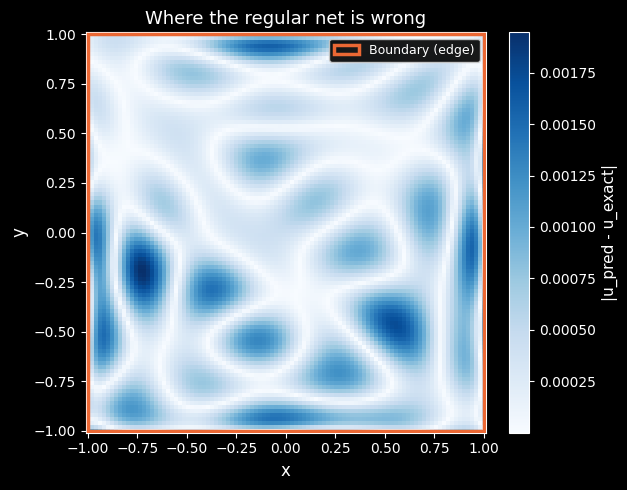

In [13]:
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(12, 5))

# --- where the errors are: spatial map of |u_pred - u_exact| ---
abs_error = np.abs(u_pred - u_exact)
im = ax.pcolormesh(Xg, Yg, abs_error, cmap="Blues", shading="auto")
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("|u_pred - u_exact|", fontsize=11)
# the domain edge is exactly the "boundary" region used in the RMSE split below
ax.add_patch(Rectangle((-1, -1), 2, 2, fill=False,
                             edgecolor="#eb6834", linewidth=2.5, zorder=5,
                             label="Boundary (edge)"))
ax.set_title("Where the regular net is wrong", fontsize=13)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

fig.tight_layout()
plt.show()

In this plot, white color means low error and dark blue color means high error.

Ok, now that we have a regular neural network capable of predicting temperatures on the surface of the metal, let's move on to the next subject which is to use physics to train a neural network, or the so-called physics-informed neural networks.



## Training in PINNs

### Introduction


Interestingly, we are going to use the same network structure as above. The same input, hidden and output layers and the same neurons. 

Inputs are going to be the $x$ and $y$ as before and the output will be the temperature $u$ as before. 

<span style="color:red;"><strong>Now if you ask what will be different then: the answer is the way we train the network.</strong></span> 

<span style="color:red;"><strong>For physics informed neural networks or PINNs, we have two loss functions.</strong></span> One for points on the boundary, which we call the <span style="color:red;"><strong>training set</strong></span>, and the other for points inside the surface which we call the <span style="color:red;"><strong>collocation points</strong></span>. 

The <span style="color:red;"><strong>collocation points</strong></span> have one main difference comparing to a regular dataset. We <span style="color:red;"><strong>no longer need</strong></span> to measure <span style="color:red;"><strong>temperature</strong></span> for them. 

That is a game changer because data collocation is not always viable. 
Some experiments are very expensive. Sometimes we have already used all useful data. Example would be large language models that have consumed all useful data on the internet. 

For the metal temperature in this course, it means we need to go to the lab and <span style="color:red;"><strong>measure the temperature</strong></span> of the metal but <span style="color:red;"><strong>only for the points on the boundary</strong></span>. That is a significant reduction in the number of measurements we need to make. 

## Loss functions

Now let's discuss the loss function that we need to minimize to train the PINN. 

The complete loss function is actually the weighted sum of two loss functions, one for the boundary, and one for the interior of the surface of the metal

$$
L = \omega_{\text{data}}\, L_{\text{data}} + \omega_{\text{pde}}\, L_{\text{pde}}
$$

The two $\omega$ are constants that determine which loss should be more important. Most of the time we can set them both equal to 1. 

The data loss is defined as in conventional neural networks. One common choice is the Mean Squared Error that we used above

$$
L_{data}(\theta) = \frac{1}{N_{data}} \sum_{i=1}^{N_{data}} \Bigg|u_{\theta}(x_i) - u_i^{data}\Bigg|^2
$$

<span style="color:red;"><strong>The only difference here is that the data points are only on the boundaries</strong></span> to enforce boundary conditions. 

Let's now implement this loss function in PyTorch. 

For that, we use the same dataset that we used to train the conventional neural network but filter out every point that is not on the boundaries.

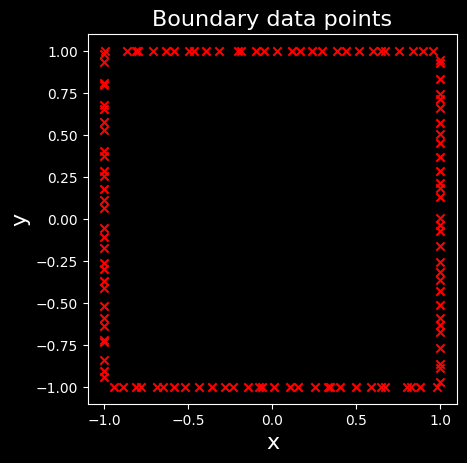

In [14]:
df_data = pd.read_csv("Utils/training_data.csv")
df_data

plt.scatter(df_data["x"], df_data["y"], marker="x", c="r")
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
plt.title("Boundary data points", fontsize=16)
plt.axis("square")
plt.show()

And in the following cell, I will convert the  x ,  y , and temperature  u  columns of the dataframe to PyTorch tensors and define the data loss function

In [15]:
x_data = torch.tensor(df_data["x"].values, dtype=torch.float32).unsqueeze(1)
y_data = torch.tensor(df_data["y"].values, dtype=torch.float32).unsqueeze(1)
u_data = torch.tensor(df_data["u"].values, dtype=torch.float32).unsqueeze(1)

L_data = mse(u(x_data, y_data), u_data)
L_data

tensor(1.5810e-07, grad_fn=<MeanBackward0>)

Now let's get to the second term in the loss function. 

It deals with data points from the interior of the metal and ensures that physics law is enforced at those places. In other words, the loss function comes from the differential equation.

First, we need to define the residual $\mathcal{F}$. That simply means we have to bring whatever is on the right hand side of the differential equation to the left-hand side so that the right-hand side is zero. 

For example, if we were dealing with the Poisson equation
$$
\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = \rho(x, y)
$$

the residual would becomes
$$
\mathcal{F} = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} - \rho(x, y)
$$

In the case of the temperature of the metal, the governing equation is Laplace 
$$
\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0
$$
whose right-hand side is already zero, hence the residual will be 
$$
\mathcal{F} = \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}
$$


Now that the residual is set, we define the loss function of the partial differential equation as the residual squared, averaged over some random collection of points from the interior of the domain of the problem. For the metal of our case, here is the loss function
$$
L_{\text{pde}}(\theta) = \frac{1}{N_c} \sum_{i=1}^{N_c} \Bigg|\frac{\partial^2 u_{\theta}( x^{(i)}, y^{(i)} )}{\partial x^2} + \frac{\partial^2 u_{\theta}( x^{(i)}, y^{(i)} )}{\partial y^2} \Bigg|^2
$$

It is important to note that <span style="color:red;"><strong>we are using the neural network prediction of the temperature </strong></span>$u_{\theta}$<span style="color:red;"><strong> in this equation.</strong></span> 

The advantage here is that we <span style="color:red;"><strong>don't need</strong></span> the true values of the <span style="color:red;"><strong>temperature</strong></span> at these points <span style="color:red;"><strong>for training</strong></span> purposes. 

We can <span style="color:red;"><strong>randomly pick</strong></span> a few $(x, y)$ pairs and insert them into the sum above and that is it.

By minimizing the physics-based loss function $L_{\text{pde}}$, we force the equation to balance out to zero at these locations, and the network learns the underlying physical laws.

Now comes another question. We already know how to use the neural network to compute the temperature $u_{\theta}(x,y)$ at a given $(x,y)$ location. 

The loss function but takes derivatives of the temperature. <span style="color:red;"><strong>How can we find the following two terms?</strong></span>
$$
\frac{\partial^2 u_{\theta}( x^{(i)}, y^{(i)} )}{\partial x^2}
$$
$$
\frac{\partial^2 u_{\theta}( x^{(i)}, y^{(i)} )}{\partial y^2} 
$$

That is where the <span style="color:red;"><strong>automatic differentiation</strong></span> method comes in.

For now just keep in mind that it is a method to take derivatives of the output layer of the neural network with respect to its input layers. 

In our case, it is a method to take derivatives of the temperature $u_{\theta}(x,y)$ with respect to $x$ and $y$. 

And, fortunately, these are all implemented in PyTorch, so you can already use them even if you don't still know how it works. 

But, let me emphasize how important it is to learn how these methods work. It is true that you can use PyTorch to take these derivatives or whatever else possible, but in that case you will be able to only solve the problems that are already solved. That means coding agents like Claude Cowork or OpenAI Codex can do it better than you and that work is already replaced. 
So, if you don't know automatic differentiation, add it to your to-be-learned list and let's move on. 

Now let's get into the implementation part. 

In the following cell, we define the residual for the Laplace equation and raise it to power two, which makes the term in front of the sum in the loss function.

Note that we use `torch.autograd.grad` (twice) to differentiate the network output with respect to its inputs. 

Also, we set `create_graph=True` so that these derivatives can themselves be differentiated during the training.

In [16]:
# residual of the Laplace equation: d^2u/dx^2 + d^2u/dy^2 = 0
def f(x, y):
    u0 = u(x, y)
    u_x = torch.autograd.grad(u0, x, grad_outputs=torch.ones_like(u0), create_graph=True)[0]
    u_y = torch.autograd.grad(u0, y, grad_outputs=torch.ones_like(u0), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    return torch.mean((u_xx + u_yy) ** 2)

We also need to import the <span style="color:red;"><strong>collocation points</strong></span> which are random data points from the interior. 

For now, we again use the same dataset that we used to train the regular network but throw out the boundary data points. We also delete the temperature column as if we didn't measure it in the first place. 

Le'ts first import the data and plot it

In [17]:
df_pde = pd.read_csv("Utils/collocation_points.csv")

df_pde

,x,y
0,0.803469,-0.907655
1,-0.581600,-0.174595
2,0.689272,0.086837
3,-0.245098,-0.887377
4,-0.478821,-0.779426
...,...,...
395,-0.800397,0.502741
396,-0.338863,-0.725232
397,-0.909372,0.401079
398,0.828855,-0.921264


Note that the rows has no true value for the temperature. That is the characteristics of the <span style="color:red;"><strong>collocation points</strong></span>. 

Let's plot them to ensure there is no data point on the boundary

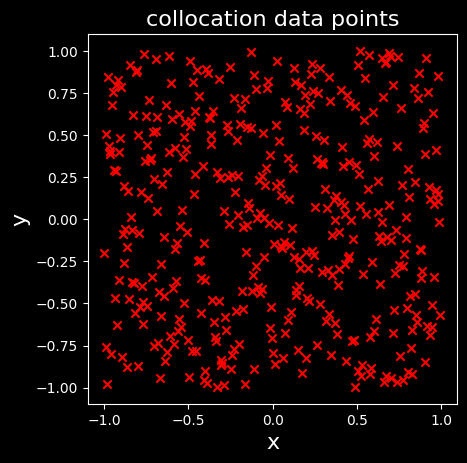

In [18]:
plt.scatter(df_pde["x"], df_pde["y"], marker="x", c="r")
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
plt.title("collocation data points", fontsize=16)
plt.axis("square")
plt.show()

And now we use the residual to implement the partial differential loss function $L_{\text{pde}}$

We convert the columns of the dataframe to torch tensors and then insert them into the residual squared function that we defined above to get the loss function

In [19]:
x_pde = torch.tensor(df_pde["x"].values, dtype=torch.float32).unsqueeze(1).requires_grad_(True)
y_pde = torch.tensor(df_pde["y"].values, dtype=torch.float32).unsqueeze(1).requires_grad_(True)

L_pde = f(x_pde, y_pde)
L_pde

tensor(0.0458, grad_fn=<MeanBackward0>)

## Training

And now comes the training part. 

We already have both pieces of the loss function: $L_{data}$ from the boundary points and $L_{pde}$ from the collocation points. We just add them together to get the total loss

$$
L(\theta) = L_{data}(\theta) + L_{pde}(\theta)
$$

Just like we did for the regular neural network, we use the Adam optimizer to repeatedly tune the free parameters $\theta$ of the network so that this total loss gets smaller and smaller.

In the following cell, we run this optimization loop for a number of epochs and keep track of how the loss decreases.

In [20]:
# reset the model weights and get a fresh optimizer, so re-running this cell
# trains from scratch instead of continuing from an already-trained model
for m in model:
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)  #Adam optimizer to repeatedly tune the free parameters $\theta$ of the network so that this total loss gets smaller and smaller.   

# number of epochs (steps)
epochs = 62000
loss_values = np.array([])
L_data_values = np.array([])
L_pde_values = np.array([])

for epoch in range(epochs):
    opt.zero_grad()

    L_data = mse(u(x_data, y_data), u_data)
    L_pde = f(x_pde, y_pde)
    loss = L_data + L_pde

    loss.backward()
    opt.step()

    if epoch % 200 == 0 or epoch == epochs - 1:
        print(f"{epoch:5}, {loss.item():.6f}")
        loss_values = np.append(loss_values, loss.item())
        L_data_values = np.append(L_data_values, L_data.item())
        L_pde_values = np.append(L_pde_values, L_pde.item())


    0, 0.878594
  200, 0.113528
  400, 0.000430
  600, 0.000229
  800, 0.000154
 1000, 0.000114
 1200, 0.000087
 1400, 0.000069
 1600, 0.000055
 1800, 0.000205
 2000, 0.000036
 2200, 0.000030
 2400, 0.000025
 2600, 0.000021
 2800, 0.000018
 3000, 0.000177
 3200, 0.000013
 3400, 0.000012
 3600, 0.000011
 3800, 0.000010
 4000, 0.000010
 4200, 0.000056
 4400, 0.000008
 4600, 0.000008
 4800, 0.000007
 5000, 0.000008
 5200, 0.000174
 5400, 0.000007
 5600, 0.000210
 5800, 0.000007
 6000, 0.000007
 6200, 0.000070
 6400, 0.000007
 6600, 0.000006
 6800, 0.000006
 7000, 0.000006
 7200, 0.000006
 7400, 0.000006
 7600, 0.001159
 7800, 0.000204
 8000, 0.000213
 8200, 0.000005
 8400, 0.000005
 8600, 0.000005
 8800, 0.000005
 9000, 0.000005
 9200, 0.000005
 9400, 0.000009
 9600, 0.000018
 9800, 0.000005
10000, 0.000540
10200, 0.000048
10400, 0.000061
10600, 0.000030
10800, 0.000470
11000, 0.000063
11200, 0.000048
11400, 0.000269
11600, 0.000099
11800, 0.000004
12000, 0.000014
12200, 0.000004
12400, 0

We now plot the total loss on a log scale and we plot the two losses separately so we can see whether the network struggles more with matching the boundary data or with satisfying the pde.

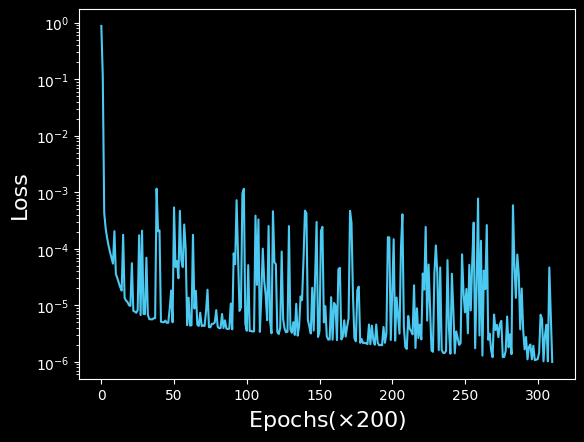

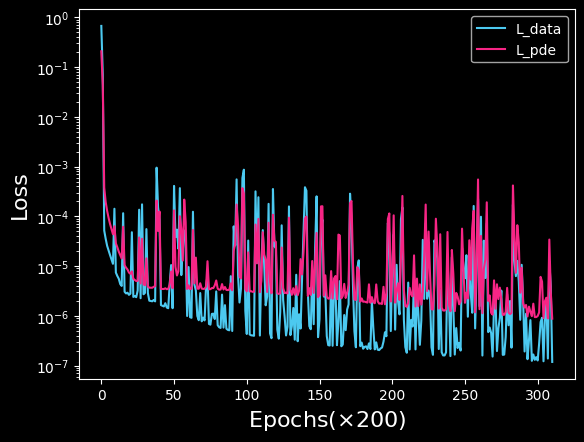

In [21]:
style = open("Utils/plot_style.py").read()
exec(style)
plt.semilogy(loss_values)
plt.xlabel("Epochs" r"($\times 200$)", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.show()

# the two losses separately, so we can see whether the network struggles more
# with matching the boundary data or with satisfying the PDE
plt.semilogy(L_data_values, label="L_data")
plt.semilogy(L_pde_values, label="L_pde")
plt.xlabel("Epochs" r"($\times 200$)", fontsize=16)
plt.ylabel("Loss", fontsize=16)
plt.legend()
plt.show()

## Evaluation

Now that the PINN is trained, let's evaluate it exactly the same way we evaluated the regular network.

We predict the temperature on the same dense grid covering the whole domain of $(x, y)$ pairs and compare against the exact solution
$$
u(x, y) = x^2 - y^2
$$

The `rmse` function, evaluation grid, and boundary/interior split are the same as in the case of regular network. 

Let's now compute the errors and print them out.

In [22]:
with torch.no_grad():
    u_pred_pinn = u(x_eval, y_eval).numpy().reshape(n, n)

print(f"Overall RMSE (PINN):  {rmse(u_pred_pinn, u_exact):.6f}")
print(f"Boundary RMSE (PINN): {rmse(u_pred_pinn[boundary_mask], u_exact[boundary_mask]):.6f}")
print(f"Interior RMSE (PINN): {rmse(u_pred_pinn[interior_mask], u_exact[interior_mask]):.6f}")

Overall RMSE (PINN):  0.000143
Boundary RMSE (PINN): 0.000344
Interior RMSE (PINN): 0.000128


The overall RMSE for the pinn is about 1x10^-4 which is a lot smaller than the regular networks(5x10^-4).

Here is a side by side comparison of the errors of the regular network versus the PINN:


| Region   | Regular net RMSE | PINN RMSE |
|----------|:-----------------:|:----------:|
| Overall  | 0.000550          | 0.000145  |
| Boundary | 0.000520          | 0.000337  |
| Interior | 0.000551          | 0.000132  |

As you can see, the PINN's RMSE is smaller than the regular network's in all metrics, even though it never saw a single true temperature label in the interior. 

Let's now plot the absolute value of the difference between the predicted and true temperatures across the surface of the metal, just like we did for the regular network.

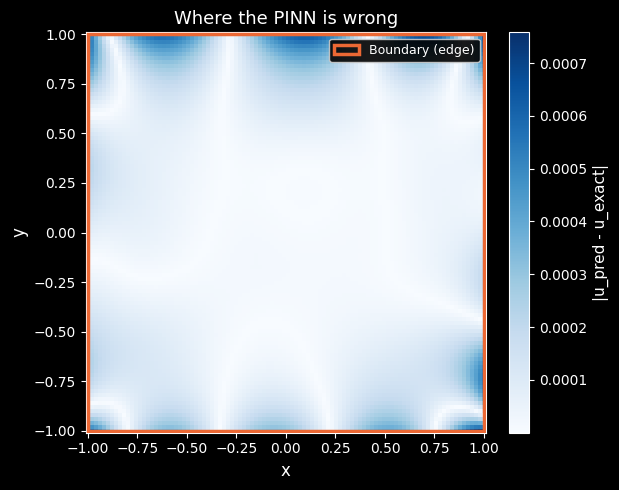

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

# --- where the errors are: spatial map of |u_pred - u_exact| ---
abs_error_pinn = np.abs(u_pred_pinn - u_exact)
im = ax.pcolormesh(Xg, Yg, abs_error_pinn, cmap="Blues", shading="auto")
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("|u_pred - u_exact|", fontsize=11)
# the domain edge is exactly the "boundary" region used in the RMSE split above
ax.add_patch(Rectangle((-1, -1), 2, 2, fill=False,
                             edgecolor="#eb6834", linewidth=2.5, zorder=5,
                             label="Boundary (edge)"))
ax.set_title("Where the PINN is wrong", fontsize=13)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

fig.tight_layout()
plt.show()

As before, in this plot, white color means low error and dark blue color means high error. Notice how much lighter this map is overall compared to the regular network's error map above. That is the 3-4x lower RMSE showing up spatially.

References

[1] [A hands-on introduction to Physics-Informed Neural Networks]